In [2]:
!unzip /content/Brain_tumour_dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0266.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0267.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0268.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0269.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0270.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0271.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0272.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0273.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0274.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0275.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0276.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0277.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0278.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0279.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0280.jpg  
  inflating: Brain_Tumor_Dataset/Negative/Te-no_0281.jpg  
  inf

In [3]:
import warnings
warnings.filterwarnings('ignore')

Importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import math
import glob

In [11]:
#Count number of images in each class (positive and negative)
root_dir="/content/Brain_Tumor_Dataset"
number_images={}
for dir in os.listdir(root_dir):
    number_images[dir]=len(os.listdir(os.path.join(root_dir,dir)))

In [12]:
number_images.items()

dict_items([('Negative', 15), ('Positive', 17)])

Creating training, validation and testing datasets

In [7]:
#Function to create train, validation and testing datasets
def creating_datasets(name,root_dir,amt):
  if not os.path.exists("./"+name):
    os.mkdir("./"+name)
    for dir in os.listdir(root_dir):
      os.makedirs("./"+name+"/"+dir)
      for img in np.random.choice(a=os.listdir(os.path.join(root_dir,dir)),
                                  size=math.floor(amt*number_images[dir])-5,
                                  replace=False
                                  ):
        O=os.path.join(root_dir,dir,img)
        D=os.path.join("./"+name,dir)
        shutil.copy(O,D)
        os.remove(O)
  else:
    print("Folder exists")


In [8]:
creating_datasets("train",root_dir,0.7)

In [9]:
creating_datasets("validation",root_dir,0.15)

In [10]:
creating_datasets("testing",root_dir,0.15)

MOdel building

In [38]:
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization, GlobalAvgPool2D
from keras.models import Sequential,load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img,img_to_array
import keras

In [14]:
model=Sequential()
model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(224, 224, 3)))

model.add(Conv2D(filters=36, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(rate=0.25))
model.add(Flatten())

model.add(Dense(units=64,activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(units=1,activation='sigmoid'))


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 36)   │         5,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 220, 220, 36)   │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 36)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,639,157 (21.51 MB)

 Trainable params: 5,638,701 (21.51 MB)

 Non-trainable params: 456 (1.78 KB)

In [16]:
model.compile(optimizer='adam',loss=keras.losses.binary_crossentropy,metrics=['accuracy'])

Data preparation for training, validation and testing

In [17]:
def preprocessingImages1(path):
  image_info=ImageDataGenerator(zoom_range=0.2, shear_range=0.2, rescale=1/255, horizontal_flip=True)
  image=image_info.flow_from_directory(directory=path,target_size=(224,224),batch_size=32,class_mode='binary')
  return image

In [18]:
train_data=preprocessingImages1("/content/train")

Found 3676 images belonging to 2 classes.


In [19]:
def preprocessingImages2(path):
  image_info=ImageDataGenerator(rescale=1/255)
  image=image_info.flow_from_directory(directory=path,target_size=(224,224),batch_size=32,class_mode='binary')
  return image

In [20]:
validation_data=preprocessingImages2("/content/validation")

Found 779 images belonging to 2 classes.


In [21]:
test_data=preprocessingImages2("/content/testing")

Found 779 images belonging to 2 classes.


In [22]:
#Early stopping and model checkpoint
from keras.callbacks import ModelCheckpoint, EarlyStopping

#Early stopping
es=EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1, mode='auto')
#ModelCheckpoint
mc=ModelCheckpoint(filepath="./best_model.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='auto')

cd=[es,mc]

Model training

In [24]:
hs=model.fit(train_data, steps_per_epoch=len(train_data), epochs=30, verbose=1, validation_data=validation_data, validation_steps=len(validation_data), callbacks=cd)

Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7943 - loss: 2.4959
Epoch 1: val_accuracy improved from -inf to 0.62131, saving model to ./best_model.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 514ms/step - accuracy: 0.7948 - loss: 2.4826 - val_accuracy: 0.6213 - val_loss: 23.1522
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8964 - loss: 0.2866
Epoch 2: val_accuracy improved from 0.62131 to 0.64313, saving model to ./best_model.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 47s 405ms/step - accuracy: 0.8964 - loss: 0.2865 - val_accuracy: 0.6431 - val_loss: 2.7898
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9253 - loss: 0.1816
Epoch 3: val_accuracy improved from 0.64313 to 0.70732, saving model to ./best_model.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 45s 394ms/step - accuracy: 0.9252 - loss: 0.1816 - val_accuracy: 0.7073 - val_loss: 1.4859
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9340 - loss: 0.1701
Epoch 4: val_accuracy improved from 0.70732 to 0.85494, saving model to ./best_model.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 403ms/step - accuracy: 0.9339 - loss: 0.1703 - val_accuracy: 0.8549 - val_loss: 0.3552
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9299 - loss: 0.2067
Epoch 5: val_accuracy improved from 0.85494 to 0.95507, saving model to ./best_model.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 399ms/step - accuracy: 0.9298 - loss: 0.2067 - val_accuracy: 0.9551 - val_loss: 0.1340
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9380 - loss: 0.1580
Epoch 6: val_accuracy improved from 0.95507 to 0.96406, saving model to ./best_model.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 398ms/step - accuracy: 0.9380 - loss: 0.1580 - val_accuracy: 0.9641 - val_loss: 0.0978
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9283 - loss: 0.1923
Epoch 7: val_accuracy did not improve from 0.96406
115/115 ━━━━━━━━━━━━━━━━━━━━ 45s 391ms/step - accuracy: 0.9283 - loss: 0.1924 - val_accuracy: 0.9576 - val_loss: 0.1932
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9402 - loss: 0.2009
Epoch 8: val_accuracy did not improve from 0.96406
115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 397ms/step - accuracy: 0.9402 - loss: 0.2005 - val_accuracy: 0.9589 - val_loss: 0.1024
Epoch 8: early stopping


In [25]:
h=hs.history
h

{'accuracy': [0.8443960547447205,
  0.8979869484901428,
  0.9192056655883789,
  0.9205658435821533,
  0.9262785911560059,
  0.9387921690940857,
  0.9230141639709473,
  0.9428727030754089],
 'loss': [0.9567806124687195,
  0.27379900217056274,
  0.18674848973751068,
  0.19769327342510223,
  0.20225565135478973,
  0.15587161481380463,
  0.19574889540672302,
  0.16364575922489166],
 'val_accuracy': [0.6213093996047974,
  0.643132209777832,
  0.707317054271698,
  0.854942262172699,
  0.9550706148147583,
  0.9640564918518066,
  0.9576380252838135,
  0.9589216709136963],
 'val_loss': [23.152225494384766,
  2.789813756942749,
  1.4858952760696411,
  0.35515710711479187,
  0.13395008444786072,
  0.09780728071928024,
  0.19323419034481049,
  0.1023968756198883]}

Plotting

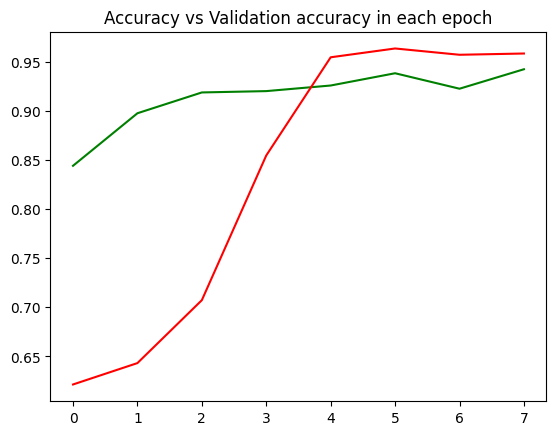

In [26]:
plt.plot(h['accuracy'],c='green')
plt.plot(h['val_accuracy'], c='red')
plt.title('Accuracy vs Validation accuracy in each epoch')
plt.show()

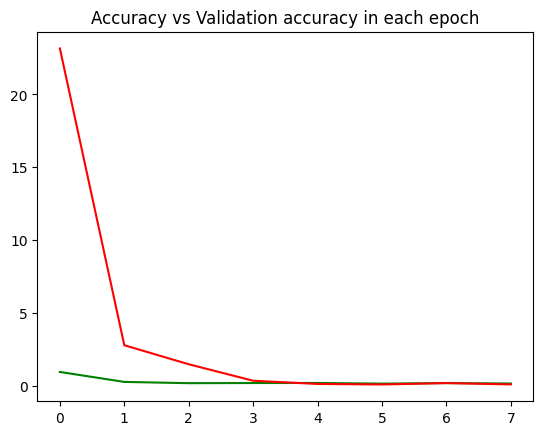

In [27]:
plt.plot(h['loss'],c='green')
plt.plot(h['val_loss'], c='red')
plt.title('Accuracy vs Validation accuracy in each epoch')
plt.show()

Model accuracy by using testing dataset

In [37]:
model=load_model("/content/best_model.h5")
acc=(model.evaluate(test_data))[1]
print(f"The accuracy of the model is {round(acc*100,3)}%")


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9457 - loss: 0.1325
The accuracy of the model is 95.379%


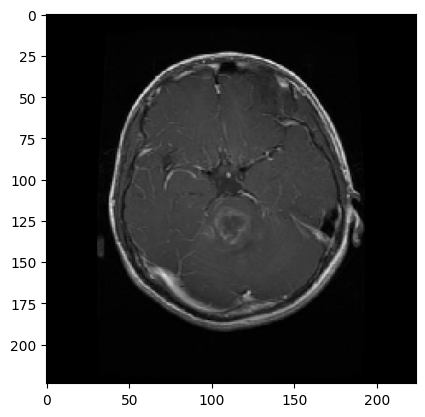

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
By MRI, it has brain tumor


In [51]:
path="/content/testing/Positive/Te-glTr_0007.jpg"
img=load_img(path,target_size=(224,224))
plt.imshow(img)
plt.show()
i=img_to_array(img)/255
i=np.expand_dims(i,axis=0)
pred=model.predict(i)
pred_class = (pred > 0.5).astype("int32")[0][0]
if(pred_class==1):
  print("By MRI, it has brain tumor")
else:
  print("By MRI, it has not tumor")


In [47]:
train_data.class_indices

{'Negative': 0, 'Positive': 1}